In [23]:
import os, sys
from importlib import reload
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


/camp/home/tootoos/working/tootoos/conda-envs/numpyro-env/lib/python3.10/site-packages/IPython/core/magics/pylab.py:166: UserWarning: pylab import has clobbered these variables: ['f', 'diag', 'split']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [129]:
a = ["foo", "barr"]
assert all(type(ai) is str for ai in a)

In [4]:
git_path = os.getenv("GIT")
proj_path = os.path.join(git_path, "glom-io-transform-release")
sys.path.append(proj_path)
os.chdir(proj_path + "/model-fitting")
os.getcwd()

'/nemo/lab/schaefera/working/tootoos/git/glom-io-transform-release/model-fitting'

In [8]:
os.environ["GLOM_IO"] = proj_path
os.environ["GLOM_IO_DATA"] = proj_path + "/data"
os.environ["OB_IO_CONN_MODELS"] = git_path + "/ob_io_conn_models"

In [220]:
import driver; reload(driver)
X0, Y0 = driver.get_data(full=True)
print("Input trials / experiment")
print([X0i.shape[-1] for X0i in X0])
print("Output trials / experiment")
print([Y0i.shape[-1] for Y0i in Y0])

Loading data from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/data/X0Y0_new.p
Input trials / experiment
[3, 3, 3, 3, 3]
Output trials / experiment
[4, 4, 4, 4, 4, 4, 3, 4, 4, 5, 4, 4]


In [25]:
import split; reload(split)
reload(driver)
XX, YY = driver.get_data(normalization="std", standardization="separate",
sampler="trials",
sampler_kwargs={"n_train":5}
)

Loading data from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/data/X0Y0_new.p
Assembling INPUTS.
Generating splits with TrialsSampler, n_train=5, which_odours=None
Materializing split...
Standardizing training, test and validation sets separately.
Normalizing by overall standard deviation.
Assembling OUTPUTS.
Generating splits with TrialsSampler, n_train=5, which_odours=None
Materializing split...
Standardizing training, test and validation sets separately.
Normalizing by overall standard deviation.


In [53]:
import pickle
with open("in.0.p", "rb") as f:
    in0 = pickle.load(f)

import split; reload(split)
import conn_models; reload(conn_models)
from conn_models import diag as diag_model
reload(diag_model)
reload(driver);
results = driver.run(in0, XX, YY)

init_args={'center': True, 'λ': np.float64(0.001)}
Regularizing z**1 - 1
bounds (-inf, inf)
Running model...
Model fitting complete.


In [55]:
results["split"].vld

RunResults(Cstar=array([[303.32601299,  66.90122954,  29.6006346 , ...,  -2.18617163,
         85.46219688, 135.86368243],
       [ 66.90122954, 103.03724375,  -3.67205364, ...,   7.86925737,
         14.14258231,  54.30338963],
       [ 29.6006346 ,  -3.67205364, 131.84437035, ...,  25.17966311,
         12.04146508,  19.16036432],
       ...,
       [ -2.18617163,   7.86925737,  25.17966311, ...,  35.20380976,
          4.41768074,   8.0394237 ],
       [ 85.46219688,  14.14258231,  12.04146508, ...,   4.41768074,
        130.99206408,  87.60420808],
       [135.86368243,  54.30338963,  19.16036432, ...,   8.0394237 ,
         87.60420808, 290.08142189]], shape=(48, 48)), Cest=array([[ 4.05447976e+02,  1.44578958e+02,  7.41701629e+01, ...,
         2.93191831e+01,  9.51818019e+01,  1.93834949e+01],
       [ 1.44578958e+02,  2.34051672e+02,  4.20795560e+01, ...,
        -2.98076429e+00,  5.10203761e+01,  3.90120937e-01],
       [ 7.41701629e+01,  4.20795560e+01,  1.07048179e+02, ...,


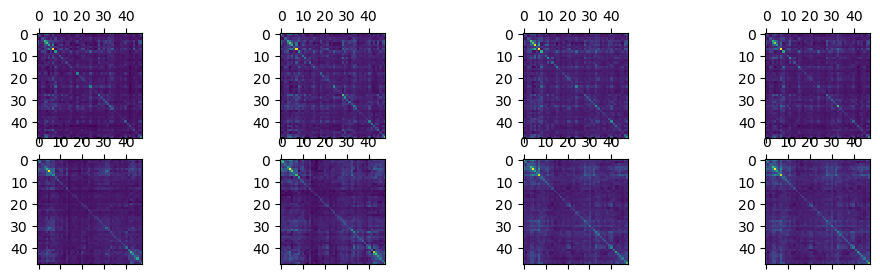

In [47]:
fig, ax = plt.subplots(2, 4, figsize=(12, 3))
ax[0, 0].matshow(results["vld"]["Cstar"])
ax[0, 1].matshow(results["test"]["Cstar"])
ax[0, 2].matshow(results["trains"][0]["Cstar"])
ax[0, 3].matshow(results["trains"][1]["Cstar"])
ax[1, 0].matshow(results["vld"]["Cest"])
ax[1, 1].matshow(results["test"]["Cest"])
ax[1, 2].matshow(results["trains"][0]["Cest"])
ax[1, 3].matshow(results["trains"][1]["Cest"])